# Chains

In [1]:
from langchain_text_splitters import RecursiveCharacterTextSplitter,CharacterTextSplitter
from langchain_community.document_loaders import TextLoader,PyMuPDFLoader
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.documents import Document
from langchain_community.vectorstores import Chroma,FAISS
import fitz  

#utility
import numpy as np
from typing import List,Dict,Any
from sentence_transformers import SentenceTransformer

from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain.chat_models import init_chat_model
from langchain_core.prompts import ChatPromptTemplate,PromptTemplate
from langchain_core.runnables import (RunnablePassthrough,RunnableMap)
from langchain_core.output_parsers import StrOutputParser
import os
import numpy as np
from langchain_community.retrievers import BM25Retriever
from langchain_classic.retrievers import EnsembleRetriever
from langchain_core.documents import Document

from langchain_classic.chains.combine_documents import create_stuff_documents_chain
from langchain_classic.chains.retrieval import create_retrieval_chain
from langchain_classic.document_loaders import WikipediaLoader
from PIL import Image
import torch
from transformers import CLIPProcessor,CLIPModel
import base64
import io
from langchain.messages import SystemMessage,HumanMessage,AIMessage,AnyMessage
from pydantic import BaseModel,Field
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware,HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage,SystemMessage
from langchain.tools import tool
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from IPython.display import Image,display

## Reducers
from typing import Annotated
from typing import Literal
from langgraph.graph.message import add_messages
import random
from  dataclasses import dataclass
from pydantic import BaseModel
from pprint import pprint
from langgraph.graph.message import add_messages
from typing import Annotated
from langgraph.prebuilt import ToolNode,tools_condition


C:\Users\kanha\AppData\Local\Temp\ipykernel_27424\4286902125.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import TextLoader,PyMuPDFLoader


In [2]:
## Step 4: LLM and prompt
import os
from dotenv import load_dotenv

load_dotenv()
os.environ["GROQ_API_KEY"] =os.getenv("OPENAI_API_KEY")
llm=init_chat_model(model="groq:llama-3.3-70b-versatile")
response=llm.invoke("Why do parrots talk?")
response

AIMessage(content="Parrots are renowned for their ability to mimic human speech and other sounds, but why do they do it? The reasons behind parrot vocalizations are complex and multifaceted. Here are some possible explanations:\n\n1. **Communication**: In the wild, parrots use vocalizations to communicate with other parrots, conveying information about food, predators, and potential mates. They may also use vocalizations to establish dominance or maintain social bonds within their flock.\n2. **Mimicry**: Parrots have an exceptional ability to mimic sounds they hear in their environment, including other birds, animals, and even human voices. This mimicry may serve as a form of play, exploration, or even a way to attract a mate.\n3. **Social learning**: Parrots are highly social animals that thrive on interaction. By mimicking human speech, they may be attempting to engage with their human caregivers, initiate play, or seek attention.\n4. **Cognitive stimulation**: Parrots are intelligen

In [3]:
from pprint import pprint
messages=[
    AIMessage(content=f"Please tell me how can i help",name="LLM")
]
messages.append(HumanMessage(content=f"I want to learn coding",name="Saksham"))
messages.append(
    AIMessage(content=f"Which language you want to learn",name="LLM")
)
messages.append(HumanMessage(content=f"I want to learn python",name="Saksham"))

for message in messages:
    message.pretty_print()

================================== Ai Message ==================================
Name: LLM

Please tell me how can i help
================================ Human Message =================================
Name: Saksham

I want to learn coding
================================== Ai Message ==================================
Name: LLM

Which language you want to learn
================================ Human Message =================================
Name: Saksham

I want to learn python


In [4]:
response=llm.invoke(messages)
response.pretty_print()

================================== Ai Message ==================================

Python is a great language to start with. Here's a step-by-step guide to help you get started:

**Why Python?**

* Easy to learn and understand
* High-level language, so you don't need to worry about memory management
* Large community and plenty of resources available
* Used in various fields like web development, data science, machine learning, automation, and more

**Setting up Python**

1. **Install Python**: Go to the official Python website ([www.python.org](http://www.python.org)) and download the latest version of Python for your operating system (Windows, macOS, or Linux).
2. **Choose a Text Editor or IDE**: A text editor or Integrated Development Environment (IDE) is where you'll write your Python code. Some popular choices include:
	* PyCharm (free community edition)
	* Visual Studio Code (free)
	* Sublime Text (free trial, then paid)
	* Atom (free)
3. **Familiarize yourself with the interface*

In [5]:
response.response_metadata

{'token_usage': {'completion_tokens': 655,
  'prompt_tokens': 73,
  'total_tokens': 728,
  'completion_time': 1.41468265,
  'completion_tokens_details': None,
  'prompt_time': 0.023662517,
  'prompt_tokens_details': None,
  'queue_time': 0.476308138,
  'total_time': 1.438345167},
 'model_name': 'llama-3.3-70b-versatile',
 'system_fingerprint': 'fp_f8b414701e',
 'service_tier': 'on_demand',
 'finish_reason': 'stop',
 'logprobs': None,
 'model_provider': 'groq'}

In [6]:
def add(a:int,b:int)->int:
    """Add a and b
    return int answer
    """
    return a+b


In [7]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.0', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001C3F6BFDC50>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001C3F6C9B150>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [8]:
ll_wi=llm.bind_tools([add])
r=ll_wi.invoke([HumanMessage(content=f"What is 2 plus 2",name="Saksham")])
r.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  add (nkhg69s20)
 Call ID: nkhg69s20
  Args:
    a: 2
    b: 2


In [9]:
r.tool_calls

[{'name': 'add',
  'args': {'a': 2, 'b': 2},
  'id': 'nkhg69s20',
  'type': 'tool_call'}]

In [10]:
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages
from typing import Annotated

In [27]:
## Using msg has state
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]


In [28]:
init_messages=[
    AIMessage(content=f"Please tell me how can i help",name="LLM")
]
init_messages.append(HumanMessage(content=f"I want to learn coding",name="Saksham"))

In [29]:
ai_message= AIMessage(content=f"Which language you want to learn",name="LLM")


In [30]:
add_messages(init_messages,ai_message)

[AIMessage(content='Please tell me how can i help', additional_kwargs={}, response_metadata={}, name='LLM', id='ba88b3ae-094d-410b-b214-6a27de74141e', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I want to learn coding', additional_kwargs={}, response_metadata={}, name='Saksham', id='c34ed374-5b82-42fb-893f-448b4ffd4c67'),
 AIMessage(content='Which language you want to learn', additional_kwargs={}, response_metadata={}, name='LLM', id='217a5ddf-32d8-473a-bb30-58ff150732cd', tool_calls=[], invalid_tool_calls=[])]

In [39]:
def llm_t(state: State):
    response = ll_wi.invoke(state["messages"])
    return {"messages": [response]}

In [40]:
from langgraph.prebuilt import ToolNode,tools_condition

In [41]:
builder=StateGraph(State)
builder.add_node("ll",llm_t)
builder.add_edge(START,"ll")
builder.add_edge("ll",END)
g=builder.compile()

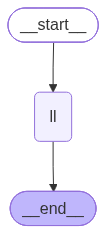

In [42]:
display(Image(g.get_graph().draw_mermaid_png()))

In [43]:
tools=[add]

In [47]:
builder = StateGraph(State)

builder.add_node("llm", llm_t)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "llm")
builder.add_conditional_edges("llm", tools_condition)
builder.add_edge("tools", END)

graph = builder.compile()

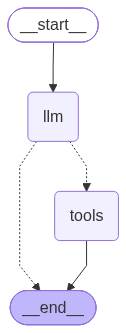

In [48]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [50]:
messags=graph.invoke({"messages":"What is 2 plus 2"})
for message in messags['messages']:
    message.pretty_print()

================================ Human Message =================================

What is 2 plus 2
================================== Ai Message ==================================
Tool Calls:
  add (cbz6b7f4r)
 Call ID: cbz6b7f4r
  Args:
    a: 2
    b: 2
================================= Tool Message =================================
Name: add

4


In [51]:
messags=graph.invoke({"messages":"What is ML"})
for message in messags['messages']:
    message.pretty_print()

================================ Human Message =================================

What is ML
================================== Ai Message ==================================

ML stands for Machine Learning. It is a subset of artificial intelligence (AI) that involves the use of algorithms and statistical models to enable machines to perform a specific task without using explicit instructions. Instead, the machine learns from data, making predictions or decisions based on that data.

Machine learning is a type of artificial intelligence that allows systems to automatically improve their performance on a task without being explicitly programmed for that task. It involves training a model on a dataset, which enables the model to make predictions or take actions based on new, unseen data.

Some key aspects of machine learning include:

1. **Data**: Machine learning relies on high-quality data to train and test models.
2. **Algorithms**: Machine learning uses various algorithms, such as dec